# 4.7 B cell lineage in the bone marrow microenvironment

Author: Xuezhu Sunny Wang

## Dataset 📊

- scRNA-seq of B cell lineage

## Steps overview 📒

- Refine B cell annotation based on marker gene expression
- - Differantially expressed gene analysis of B cell subtypes

In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
library(dplyr)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1_bcell<-readRDS(file='sce1_bcell.rds')

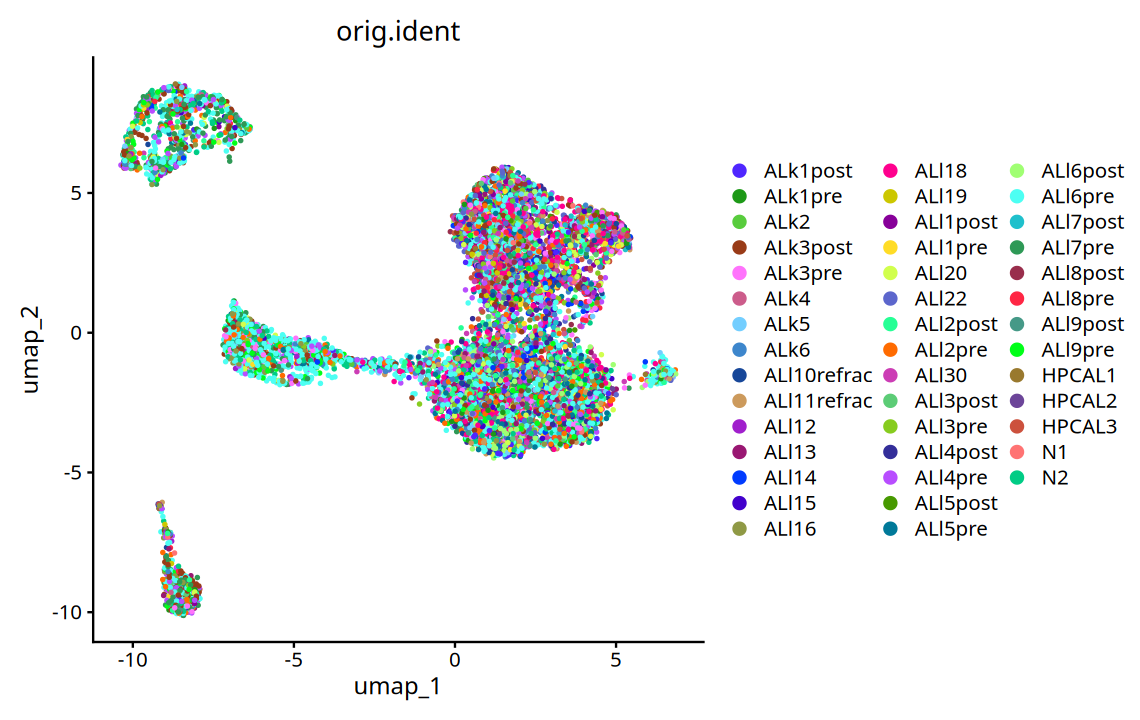

In [3]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_bcell, pt.size=0.5,reduction = "umap", group.by = c("orig.ident"),label=F) 

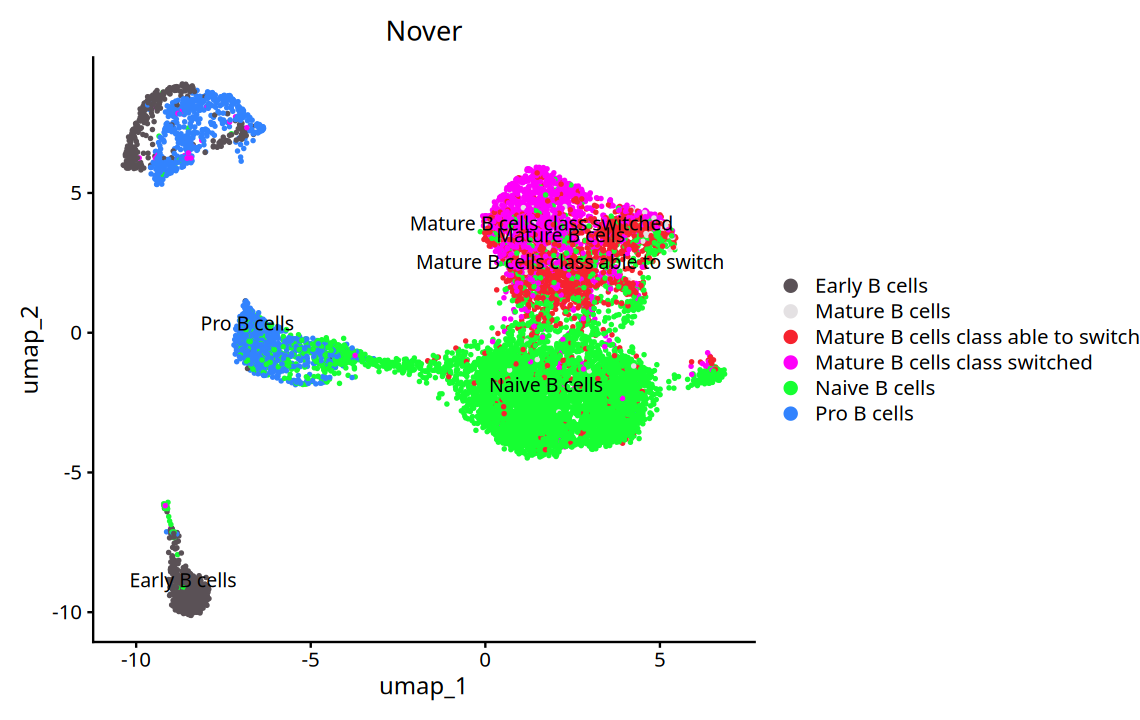

In [4]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_bcell, pt.size=0.5,reduction = "umap", group.by = c("Nover"),label=T) 

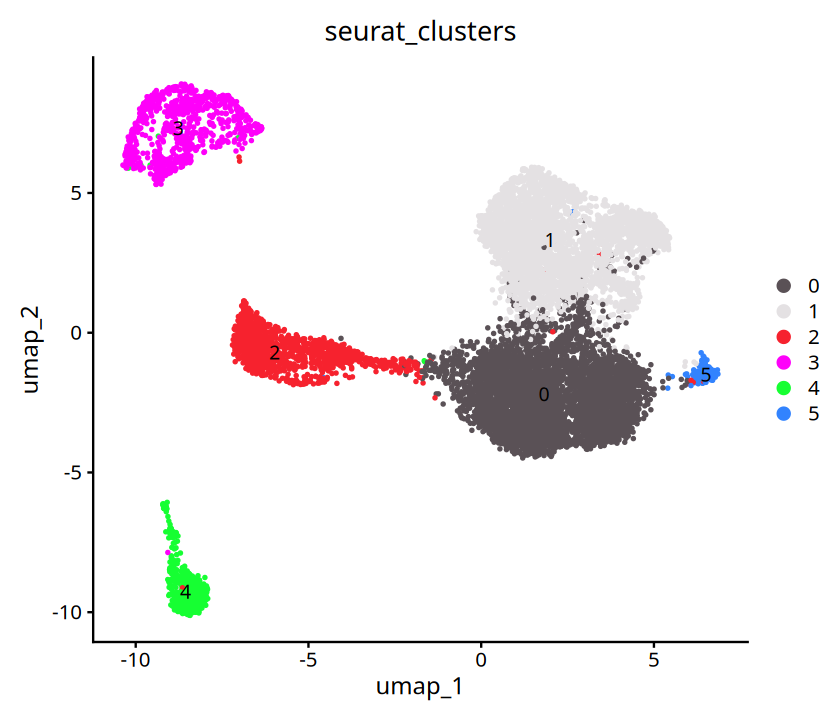

In [5]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=7)
DimPlot_scCustom(sce1_bcell, pt.size=0.5,reduction = "umap", group.by = c("seurat_clusters"),label=T) 


Attaching package: ‘purrr’


The following object is masked from ‘package:GenomicRanges’:

    reduce


The following object is masked from ‘package:IRanges’:

    reduce


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `seurat_clusters` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.


png 
  3

Warning message in DoHeatmap(sce_small, features = features_for_heatmap, group.by = "seurat_clusters", :
“The following features were omitted as they were not found in the scale.data slot for the RNA assay: MMP28, SHANK3, LINC02580, AC087627.1, AL391840.1, LINC00114, SCHIP1, DUSP26, TICRR, RDM1, CDC25C, ADAM23, CDHR3, AC016866.1, CECR2, TOX2, LINC00472, COCH, TMEM273, TFEC, TEX9, ZBTB32, CD200, SKAP1, CHI3L2, COL19A1, PLPP5, IL4R, KCNG1”



Outputs written to:/lab-share/home/Public/data/arsenal_1118/markers_out_bcell
- top markers (long):            top10_markers_long.csv
- gene name table (wide):        top10_markers_genename_table_wide.csv
- stats by raB (tidy):          top10_markers_stats_by_raB.csv
- Heatmap (cluster-average PNG): heatmap_cluster_avg_top10.png
- Heatmap (cell-level PNG):      heatmap_cell_level_top10.png


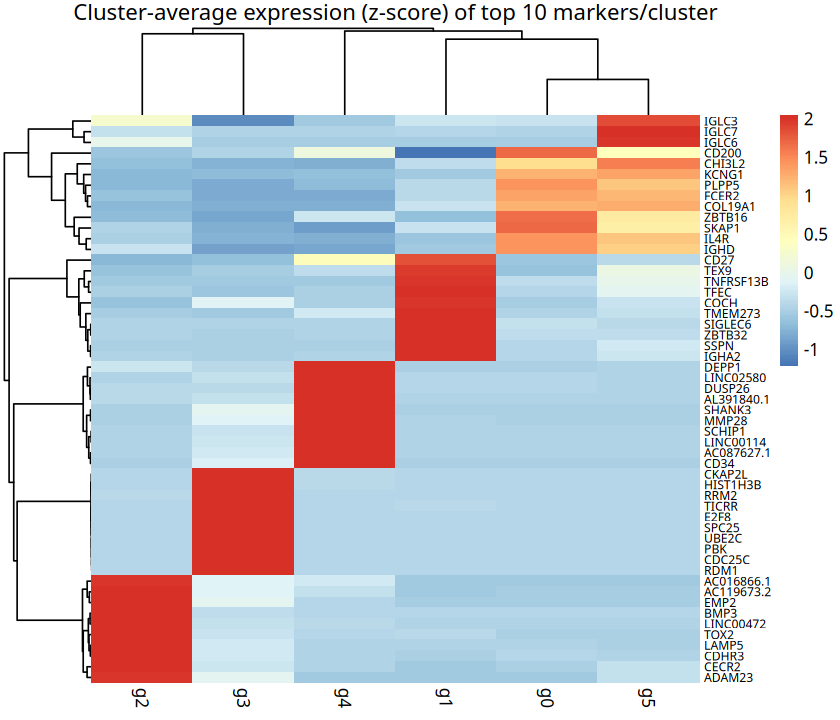

In [6]:
# ---- Packages ----
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(purrr)
  library(pheatmap)
  library(ggplot2)
# ---- Settings you can tweak ----
Idents(sce1_bcell) <- "seurat_clusters"   # make sure clusters are the active identities
TOP_N <- 10                               # how many markers per cluster to keep
LOGFC_MIN <- 1                            # minimum avg_log2FC
PADJ_MAX <- 0.05                          # maximum adjusted p-value
DOWNSAMPLE_CELLS <- 100                   # cells per cluster for the cell-level heatmap (for readability)
OUT_DIR <- "markers_out_bcell"

if (!dir.exists(OUT_DIR)) dir.create(OUT_DIR)

# ---- 1) Find markers (positive only) ----
markers_all <- FindAllMarkers(
  sce1_bcell,
  only.pos = TRUE,              # positive markers
  test.use = "wilcox",          # default is fine; change if you prefer
  logfc.threshold = 0,          # we'll filter below to be explicit
  min.pct = 0.1
)

# Keep useful columns & filter
markers_filt <- markers_all %>%
  select(gene, cluster, p_val, avg_log2FC, pct.1, pct.2, p_val_adj) %>%
  filter(avg_log2FC >= LOGFC_MIN, p_val_adj <= PADJ_MAX)

# ---- 2) Top-N per cluster (by effect size) ----
top_markers <- markers_filt %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = TOP_N, with_ties = FALSE) %>%
  mutate(raB = row_number()) %>%
  ungroup()

# Save a tidy long table of top markers (nice to read / sort)
write.csv(top_markers, file.path(OUT_DIR, sprintf("top%d_markers_long.csv", TOP_N)), row.names = FALSE)

# ---- 3) A wide "gene name table" (rows = raB, columns = clusters) ----
# This is the quick visual list you asked for: each column is a cluster, each row one marker raB.
gene_name_table <- top_markers %>%
  arrange(cluster, raB) %>%
  select(cluster, raB, gene) %>%
  pivot_wider(names_from = cluster, values_from = gene) %>%
  arrange(raB)

write.csv(gene_name_table, file.path(OUT_DIR, sprintf("top%d_markers_genename_table_wide.csv", TOP_N)), row.names = FALSE)

# ---- 4) Heatmap: cluster-average expression of selected markers ----
# Pick unique genes across clusters
sel_genes <- unique(top_markers$gene)
sel_genes <- sel_genes[sel_genes %in% rownames(sce1_bcell)]  # keep only present genes

# Average expression by cluster (RNA/data slot: log-normalized recommended)
avg_mat <- AverageExpression(sce1_bcell, assays = "RNA", slot = "data", group.by = "seurat_clusters")$RNA
avg_mat_sel <- avg_mat[intersect(sel_genes, rownames(avg_mat)), , drop = FALSE]

# Optional: row z-score for better contrast across clusters
row_zscore <- function(m) {
  t(scale(t(m)))
}
avg_mat_z <- row_zscore(as.matrix(avg_mat_sel))

# pheatmap (cluster-average)
png(file.path(OUT_DIR, sprintf("heatmap_cluster_avg_top%d.png", TOP_N)),
    width = 1600, height = 200 + 15 * nrow(avg_mat_z), res = 150)
pheatmap(
  avg_mat_z,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  show_rownames = TRUE,
  show_colnames = TRUE,
  main = sprintf("Cluster-average expression (z-score) of top %d markers/cluster", TOP_N),
  fontsize_row = 7,
  fontsize_col = 10,
  border_color = NA
)
dev.off()

# ---- 5) Heatmap: cell-level (downsampled) for the same marker set ----
# Downsample cells per cluster for readability
set.seed(1)
sce_small <- subset(sce1_bcell, downsample = DOWNSAMPLE_CELLS)

# Reorder clusters by a simple heuristic (optional): by size
cl_order <- names(sort(table(Idents(sce_small)), decreasing = TRUE))
sce_small$seurat_clusters <- factor(Idents(sce_small), levels = cl_order)

# DoHeatmap prefers features present & not duplicated
features_for_heatmap <- unique(sel_genes)

# Draw and save with ggsave
p <- DoHeatmap(
  sce_small,
  features = features_for_heatmap,
  group.by = "seurat_clusters",
  label = TRUE,                         # show cluster labels above
  size = 4
) + ggtitle(sprintf("Cell-level heatmap (downsampled %d cells/cluster)", DOWNSAMPLE_CELLS)) +
  theme(plot.title = element_text(hjust = 0.5))

ggsave(file.path(OUT_DIR, sprintf("heatmap_cell_level_top%d.png", TOP_N)),
       plot = p, width = 12, height = max(6, 0.18 * length(features_for_heatmap)), dpi = 200)

# ---- 6) Also save a wide statistics table (one row per cluster per raB) ----
# Each row has gene + stats at a given raB within its cluster.
wide_stats <- top_markers %>%
  arrange(raB, cluster) %>%
  select(raB, cluster, gene, avg_log2FC, p_val_adj, pct.1, pct.2)

write.csv(wide_stats, file.path(OUT_DIR, sprintf("top%d_markers_stats_by_raB.csv", TOP_N)), row.names = FALSE)

# ---- 7) Console message with pointers ----
cat("\nOutputs written to:", normalizePath(OUT_DIR), "\n",
    "- top markers (long):            ", sprintf("top%d_markers_long.csv", TOP_N), "\n",
    "- gene name table (wide):        ", sprintf("top%d_markers_genename_table_wide.csv", TOP_N), "\n",
    "- stats by raB (tidy):          ", sprintf("top%d_markers_stats_by_raB.csv", TOP_N), "\n",
    "- Heatmap (cluster-average PNG): ", sprintf("heatmap_cluster_avg_top%d.png", TOP_N), "\n",
    "- Heatmap (cell-level PNG):      ", sprintf("heatmap_cell_level_top%d.png", TOP_N), "\n", sep = "")


In [7]:
Idents(sce1_bcell)<-'Nover'

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# cytotoxicity, exhaustion, activation, and cytokine-dependent

# all marker
allgene <- c(
   #'HSC/LMPP','CLP','proB','preBI','preBII','immatureB','matureB','activatedB','cycling'
   # conventional B cell lineage
   "CD19","MS4A1","CD79A","CD34",
   # Naïve / transitional B cells
  "KCNG1","ZBTB16","IL4R","FCER2","PLPP5",
  "CHI3L2","IGHD","SKAP1","CD200",
   # Class-switched memory B cell
  "SSPN","SIGLEC6","IGHA2","ZBTB32","TEX9",
  "ST6GAL1","IL4I1","GPR18","CD27",
  # Activated / plasmablast-precursor B cells
  "LAMP5","EMP2", "PCOLCE2","TNFRSF13B","MZB1","DERL3",
  # Proliferating B cells
  "CDC25C","PBK","CKAP2L","UBE2C","E2F","MKI67","TOP2A","BIRC5","CCNB2",
   # Cluster 4 — lncRNA-rich / regulatory B cells
  "DUSP26","SCHIP1","CD34","DEPP1","SHAB3","MMP28",
   #Cluster 5 — Plasma cells (lambda light chain)
  "IGLC7","IGLC6","SDC1","PRDM1",
   "CD38"
)



In [8]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_bcell, features = unique(allgene), split.by = "seurat_clusters", scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
“The following requested variables were not found: E2F, SHAB3”



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




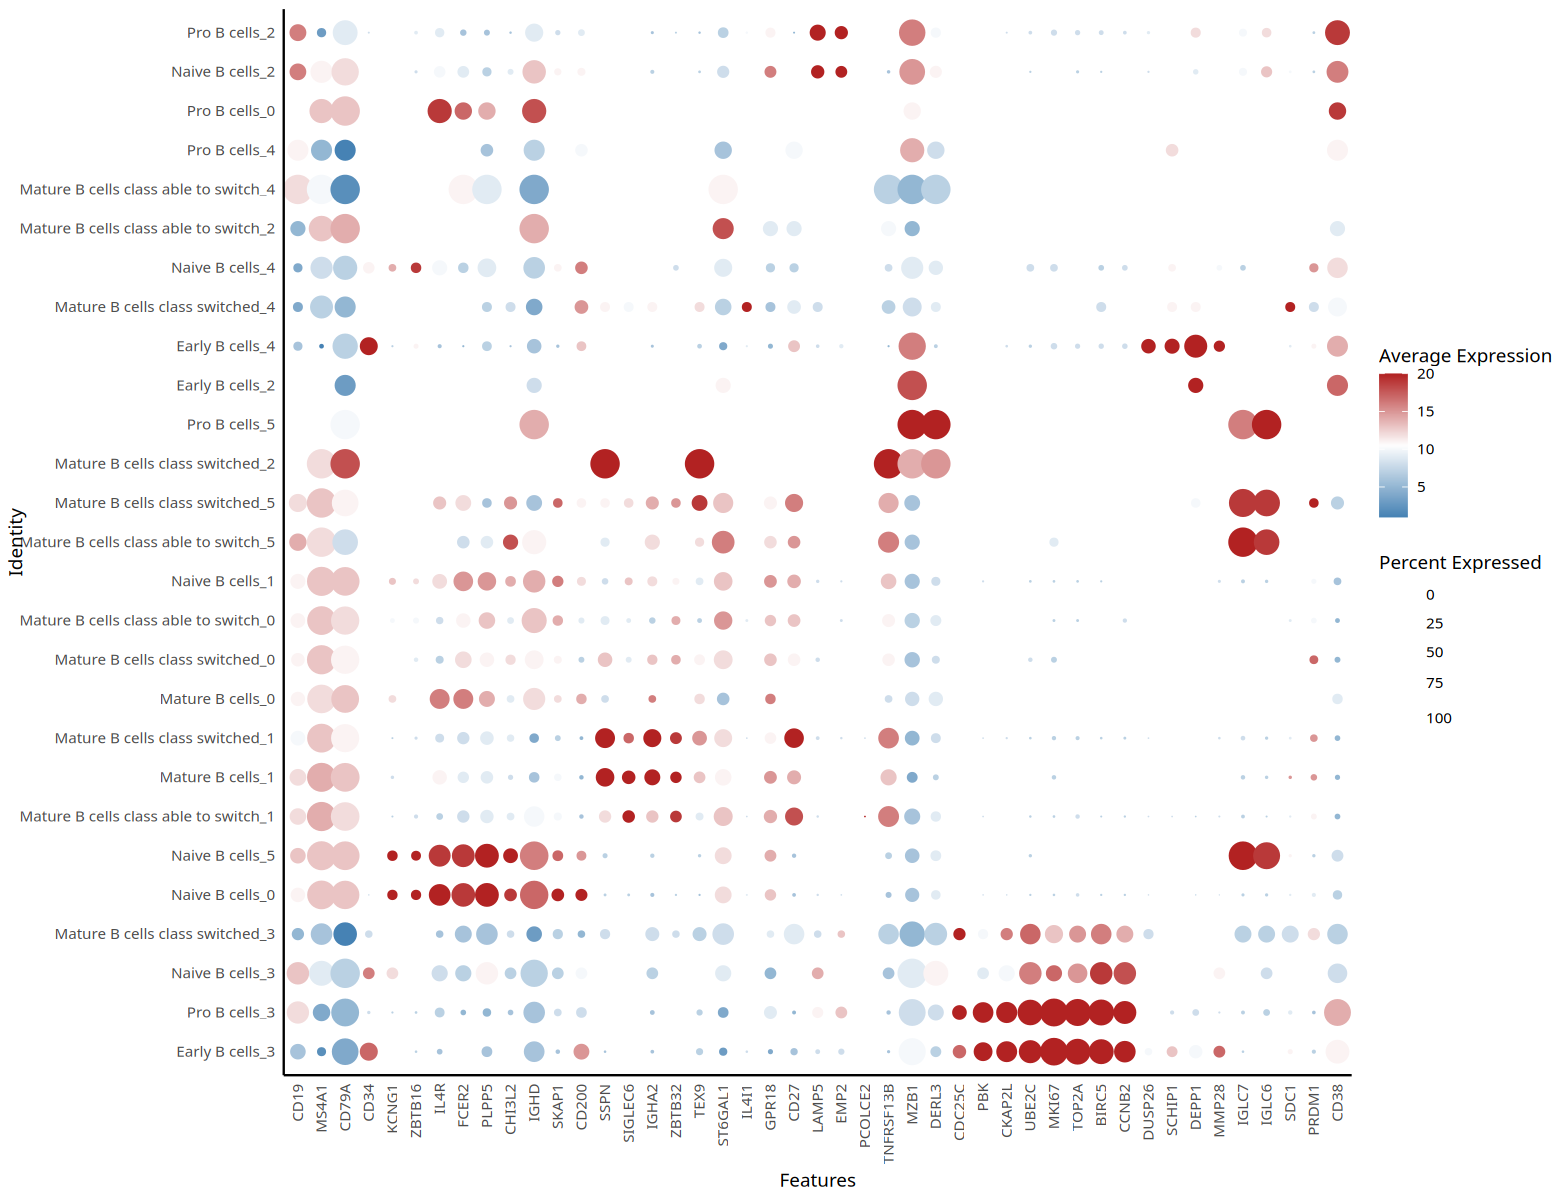

In [9]:
options(repr.plot.height=10,repr.plot.width=13)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [10]:
# Create a named vector: keys = original label, values = new label
sce1_bcell@meta.data$Annotation<-paste(sce1_bcell@meta.data$Nover, sce1_bcell@meta.data$'seurat_clusters',sep='_')

replacements <- c(
  "Mature B cells class able to switch_1"="Mature B cells class able to switch",
  "Mature B cells class able to switch_0"="Naive B cells",
  "Mature B cells class able to switch_2"="Activated B cells",
  "Mature B cells class able to switch_5"='Plasmablasts',
  "Mature B cells class able to switch_4"='Regulatory B cells',
  "Naive B cells_0"="Naive B cells",
  "Naive B cells_1"="Naive B cells",
  "Naive B cells_4"='Regulatory B cells',
  "Naive B cells_2"='Activated B cells',
  "Naive B cells_5"='Plasmablasts',
  "Naive B cells_3"='B cells_cycling',
  "Mature B cells_1"="Mature B cells class switched",
  "Mature B cells_0"='Naive B cells',
  "Early B cells_4"='Regulatory B cells',
  "Early B cells_3"='B cells_cycling',
  "Early B cells_2"='Regulatory B cells',
  "Mature B cells class switched_1"="Mature B cells class switched",
  "Mature B cells class switched_0"="Naive B cells",
  "Mature B cells class switched_3"='B cells_cycling',
  "Mature B cells class switched_5"='Plasmablasts',
  "Mature B cells class switched_2"='Mature B cells class switched',
  "Mature B cells class switched_4"='Regulatory B cells',
  "Pro B cells_3"='B cells_cycling',
  "Pro B cells_2"='Activated B cells',
  "Pro B cells_0"='Naive B cells',
  "Pro B cells_4"='Regulatory B cells',
  "Pro B cells_5"='Plasmablasts'
)
# Apply the replacement in one go:
sce1_bcell@meta.data$Annotation <- replacements[sce1_bcell@meta.data$Annotation]

# If any value not matched, return original:
sce1_bcell@meta.data$Annotation[is.na(sce1_bcell@meta.data$Annotation)] <- 
  paste(sce1_bcell@meta.data$Nover, sce1_bcell@meta.data$seurat_clusters, sep = "_")[is.na(sce1_bcell@meta.data$Annotation)]


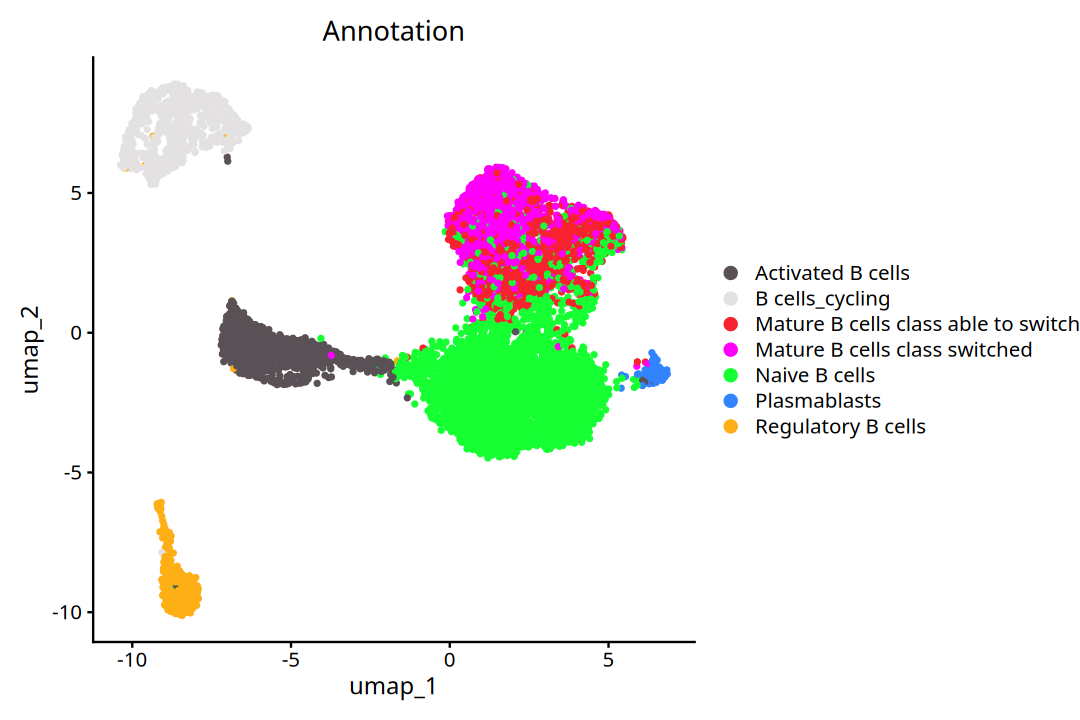

In [11]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
DimPlot_scCustom(sce1_bcell , pt.size=1,reduction = "umap", group.by = c("Annotation"),label=F) 

In [12]:
p<-DimPlot_scCustom(sce1_bcell , pt.size=1,reduction = "umap", group.by = c("Annotation"),label=F) 
ggsave("Figsbcell.pdf", plot = p, width = 9, height =6)


In [12]:
sce1_bcell@meta.data$barcode<-rownames(sce1_bcell@meta.data)
label<-sce1_bcell@meta.data[,c('barcode','Annotation')]
write.csv(label,file='Bcell.noverlabel.csv')

In [13]:
library(RColorBrewer)

Idents(sce1_bcell)<-'Annotation'

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_bcell, features = unique(allgene),  scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
“The following requested variables were not found: E2F, SHAB3”


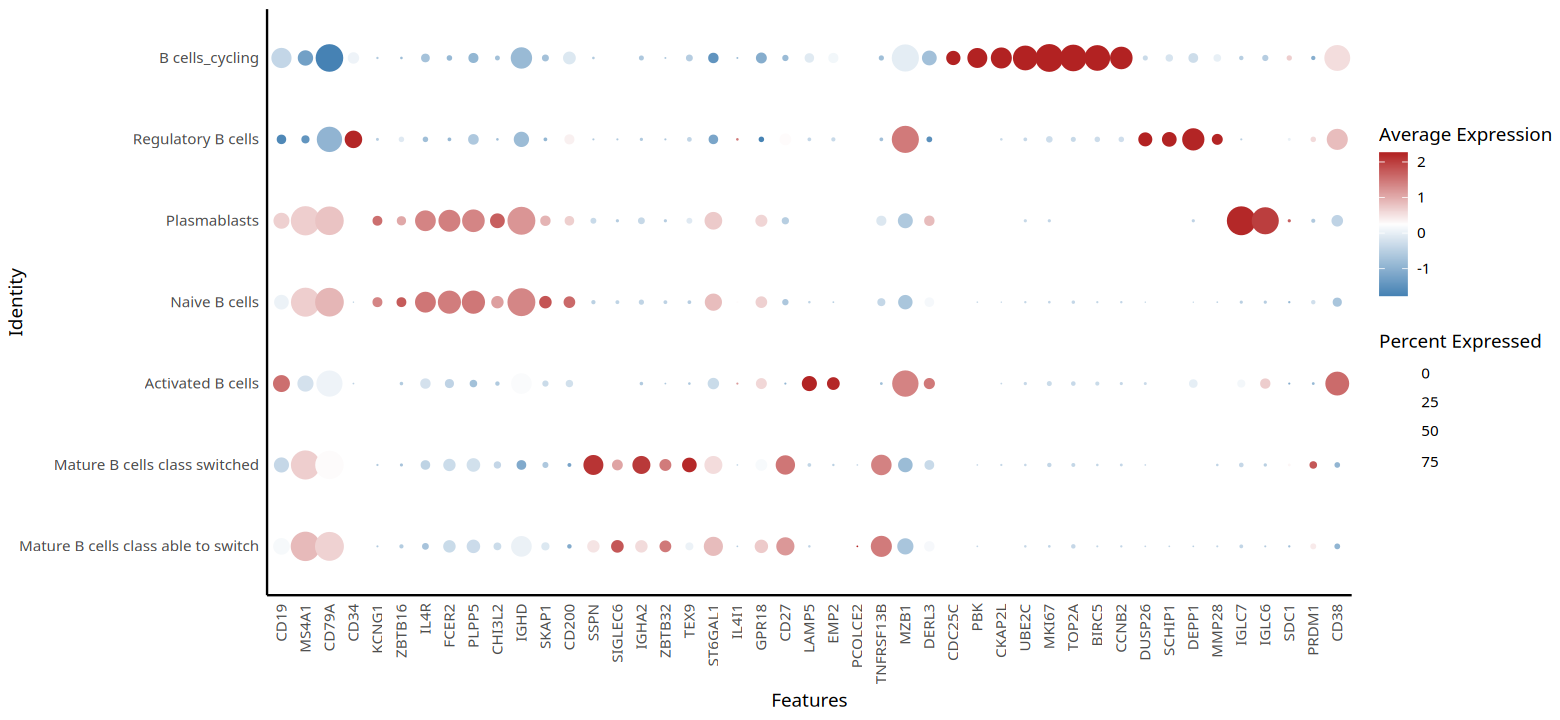

In [14]:
options(repr.plot.height=6,repr.plot.width=13)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [18]:
ggsave("Figs11F.pdf", plot = p, width = 11, height =6)


In [15]:
sce1_bcell$label <- sce1_bcell$orig.ident
sce1_bcell$label <- ifelse(grepl("N1|N2", sce1_bcell$label), "Normal", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALl9pre|ALl8pre|ALl6pre|ALl30|ALl20|ALl19|ALl18|ALl14|ALl13|ALl1pre|ALk4|ALk1pre", sce1_bcell$label), "AL_CR_pre", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALl9post|ALl8post|ALl6post|ALl1post|ALk1post", sce1_bcell$label), "AL_CR_post", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALl3pre|ALl22|ALk3pre|ALk2|HPCAL2", sce1_bcell$label), "AL_VGPR_pre", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALk3post|ALl3post", sce1_bcell$label), "AL_VGPR_post", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALl7pre|ALl12|ALk6|HPCAL1", sce1_bcell$label), "AL_NR/SD_pre", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALl7post", sce1_bcell$label), "AL_NR/SD_post", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALl5pre|ALl4pre|ALl2pre|ALl16", sce1_bcell$label), "AL_PR_pre", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("ALl5post|ALl4post|ALl2post|ALl11refrac|ALl10refrac", sce1_bcell$label), "AL_PR_post", sce1_bcell$label)
sce1_bcell$label <- ifelse(grepl("HPCAL3|ALl15|ALk5", sce1_bcell$label), "AL_NotRecorded", sce1_bcell$label)

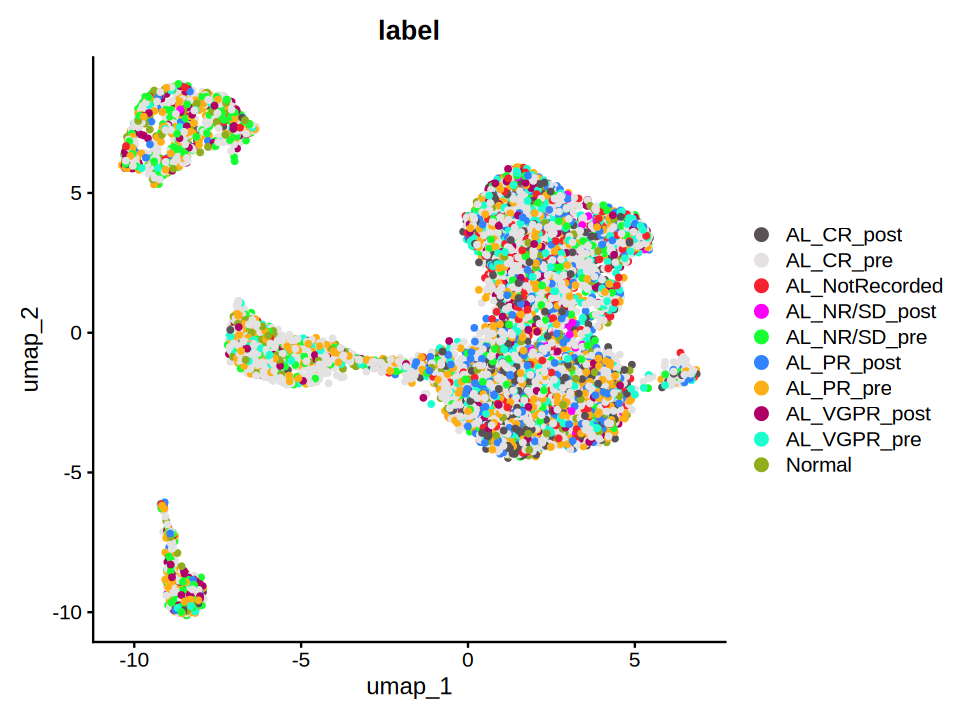

In [16]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(sce1_bcell , pt.size=1,reduction = "umap", group.by = c("label"),label=F) 

Calculating cluster Mature B cells class able to switch

Calculating cluster Naive B cells

Calculating cluster Mature B cells class switched

Calculating cluster Regulatory B cells

Calculating cluster B cells_cycling

Calculating cluster Activated B cells

Calculating cluster Plasmablasts



png 
  3

Warning message in DoHeatmap(sce_small, features = features_for_heatmap, group.by = "seurat_clusters", :
“The following features were omitted as they were not found in the scale.data layer for the RNA assay: AC005332.7, NEIL1, LDLRAD4, TMEM38A, MYO1C, LAMA5, IGLC5, AL133467.1, BTBD3, AL157402.1, NSMCE1, RAPGEF5, CDC25B, WASF1, DCAF12, LINC02227, HIP1, GAS7, NOXA1, RARA-AS1, HRK, DTX1, AL132996.1, RIMS3, APBB2, CCDC191, KANK2, SMAD7, BEST3, AC016168.2, ACSM3, DNMT3B, ADAM23, CDHR3, AC016866.1, CECR2, TOX2, LINC00472, SAPCD2, KIF18B, MELK, TICRR, RDM1, CDC25C, CCDC81, ITGA5, PLEKHA5, LINC01226, TNFRSF1A, MT1X, HHIP, PSD3, SMIM3, MYO5C, RPS4Y2, XXYLT1-AS2, LEF1-AS1, MIR3142HG, PXDN, HMHB1, SLC8A1-AS1, RNF152, SOCS2-AS1, AL590226.1, ST3GAL6, ERG, ADGRE2, SH2D4B, MMP28, SHANK3, LINC02580, AC087627.1, AL391840.1, LINC00114, SCHIP1, DUSP26, S100A4, TCF7, NEK6, ITGAM, ANXA2, FXYD1, HOPX, ITGAX, CAPN2, NIBAN1, GRAMD1C, HIPK2, ZBTB38, S100A10, CD70, CD86, FAS, ITGB1, EPHA4, SHISA8, CD247, BAIAP3

ERROR: [1m[33mError[39m in `ggsave()`:[22m
[1m[22m[33m![39m Dimensions exceed 50 inches (`height` and `width` are specified in
  [3minches[23m not pixels).
[36mℹ[39m If you're sure you want a plot that big, use `limitsize = FALSE`.


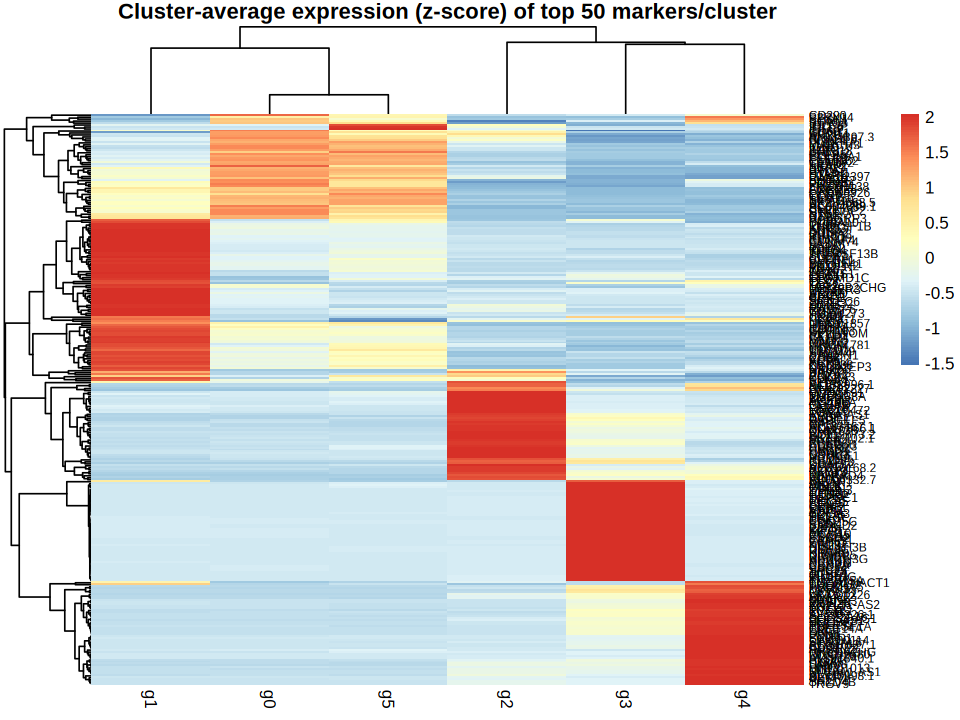

In [17]:
# ---- Packages ----
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(purrr)
  library(pheatmap)
  library(ggplot2)
# ---- Settings you can tweak ----
Idents(sce1_bcell) <- "Annotation"   # make sure clusters are the active identities
TOP_N <- 50                               # how many markers per cluster to keep
LOGFC_MIN <- 1                            # minimum avg_log2FC
PADJ_MAX <- 0.05                          # maximum adjusted p-value
DOWNSAMPLE_CELLS <- 100                   # cells per cluster for the cell-level heatmap (for readability)
OUT_DIR <- "markers_out_bcell"

if (!dir.exists(OUT_DIR)) dir.create(OUT_DIR)

# ---- 1) Find markers (positive only) ----
markers_all <- FindAllMarkers(
  sce1_bcell,
  only.pos = TRUE,              # positive markers
  test.use = "wilcox",          # default is fine; change if you prefer
  logfc.threshold = 0,          # we'll filter below to be explicit
  min.pct = 0.1
)

# Keep useful columns & filter
markers_filt <- markers_all %>%
  select(gene, cluster, p_val, avg_log2FC, pct.1, pct.2, p_val_adj) %>%
  filter(avg_log2FC >= LOGFC_MIN, p_val_adj <= PADJ_MAX)

# ---- 2) Top-N per cluster (by effect size) ----
top_markers <- markers_filt %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = TOP_N, with_ties = FALSE) %>%
  mutate(ramono = row_number()) %>%
  ungroup()

# Save a tidy long table of top markers (nice to read / sort)
write.csv(top_markers, file.path(OUT_DIR, sprintf("top%d_markers_long.csv", TOP_N)), row.names = FALSE)

# ---- 3) A wide "gene name table" (rows = ramono, columns = clusters) ----
# This is the quick visual list you asked for: each column is a cluster, each row one marker ramono.
gene_name_table <- top_markers %>%
  arrange(cluster, ramono) %>%
  select(cluster, ramono, gene) %>%
  pivot_wider(names_from = cluster, values_from = gene) %>%
  arrange(ramono)

write.csv(gene_name_table, file.path(OUT_DIR, sprintf("top%d_markers_genename_table_wide.csv", TOP_N)), row.names = FALSE)

# ---- 4) Heatmap: cluster-average expression of selected markers ----
# Pick unique genes across clusters
sel_genes <- unique(top_markers$gene)
sel_genes <- sel_genes[sel_genes %in% rownames(sce1_bcell)]  # keep only present genes

# Average expression by cluster (RNA/data slot: log-normalized recommended)
avg_mat <- AverageExpression(sce1_bcell, assays = "RNA", slot = "data", group.by = "seurat_clusters")$RNA
avg_mat_sel <- avg_mat[intersect(sel_genes, rownames(avg_mat)), , drop = FALSE]

# Optional: row z-score for better contrast across clusters
row_zscore <- function(m) {
  t(scale(t(m)))
}
avg_mat_z <- row_zscore(as.matrix(avg_mat_sel))

# pheatmap (cluster-average)
png(file.path(OUT_DIR, sprintf("heatmap_cluster_avg_top%d.png", TOP_N)),
    width = 1600, height = 200 + 15 * nrow(avg_mat_z), res = 150)
pheatmap(
  avg_mat_z,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  show_rownames = TRUE,
  show_colnames = TRUE,
  main = sprintf("Cluster-average expression (z-score) of top %d markers/cluster", TOP_N),
  fontsize_row = 7,
  fontsize_col = 10,
  border_color = NA
)
dev.off()

# ---- 5) Heatmap: cell-level (downsampled) for the same marker set ----
# Downsample cells per cluster for readability
set.seed(1)
sce_small <- subset(sce1_bcell, downsample = DOWNSAMPLE_CELLS)

# Reorder clusters by a simple heuristic (optional): by size
cl_order <- names(sort(table(Idents(sce_small)), decreasing = TRUE))
sce_small$seurat_clusters <- factor(Idents(sce_small), levels = cl_order)

# DoHeatmap prefers features present & not duplicated
features_for_heatmap <- unique(sel_genes)

# Draw and save with ggsave
p <- DoHeatmap(
  sce_small,
  features = features_for_heatmap,
  group.by = "seurat_clusters",
  label = TRUE,                         # show cluster labels above
  size = 4
) + ggtitle(sprintf("Cell-level heatmap (downsampled %d cells/cluster)", DOWNSAMPLE_CELLS)) +
  theme(plot.title = element_text(hjust = 0.5))

ggsave(file.path(OUT_DIR, sprintf("heatmap_cell_level_top%d.png", TOP_N)),
       plot = p, width = 12, height = max(6, 0.18 * length(features_for_heatmap)), dpi = 200)

# ---- 6) Also save a wide statistics table (one row per cluster per ramono) ----
# Each row has gene + stats at a given ramono within its cluster.
wide_stats <- top_markers %>%
  arrange(ramono, cluster) %>%
  select(ramono, cluster, gene, avg_log2FC, p_val_adj, pct.1, pct.2)

write.csv(wide_stats, file.path(OUT_DIR, sprintf("top%d_markers_stats_by_ramono.csv", TOP_N)), row.names = FALSE)

# ---- 7) Console message with pointers ----
cat("\nOutputs written to:", normalizePath(OUT_DIR), "\n",
    "- top markers (long):            ", sprintf("top%d_markers_long.csv", TOP_N), "\n",
    "- gene name table (wide):        ", sprintf("top%d_markers_genename_table_wide.csv", TOP_N), "\n",
    "- stats by ramono (tidy):          ", sprintf("top%d_markers_stats_by_ramono.csv", TOP_N), "\n",
    "- Heatmap (cluster-average PNG): ", sprintf("heatmap_cluster_avg_top%d.png", TOP_N), "\n",
    "- Heatmap (cell-level PNG):      ", sprintf("heatmap_cell_level_top%d.png", TOP_N), "\n", sep = "Umononown")
